In [16]:
import numpy as np
from numpy.linalg import norm
import math, random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [17]:
#spatial funcs for WoS

def closestPoint(v, s):
    u = s[1] - s[0]
    rate = max(0, min(u.dot(v - s[0])/u.dot(u), 1))
    return (s[0] + rate*(s[1] - s[0]))

def shortestDistance(v, segments):
    r = float("inf")
    for s in segments:
        u = closestPoint(v, s)
        if norm(v - u) < r:
            r = norm(v - u)
    return r

In [18]:
def solver(v, segments, g, eps = 0.01, nWalks = 10, maxSteps = 16):
    vWalks = 0   
    sumEst = 0
    for i in range(0, nWalks):
        x0 = v
        for step in range(0, maxSteps): 
            #r = min([shortestDistance(x0, segments), maxR])
            r = shortestDistance(x0, segments)
            if r < eps: 
                sumEst += g(x0)
                vWalks += 1
                #print("walk: " + str(vWalks) + " hit " + str(x0) + " boundary " + str(g(x0)))
                break
            theta = random.uniform(0, 2*math.pi)
            x0 = x0 + np.array([r * math.cos(theta), r * math.sin(theta)])
    if vWalks == 0:
        return 0
    return sumEst/vWalks

In [19]:
# set up the problem
segments = [np.array([[-1, -1], [-1, 1]]), np.array([[-1, -1], [1, -1]]), np.array([[1, -1], [1, 1]]), np.array([[-1, 1], [1, 1]])]
#v = np.array([0, 0])
def boundary(v):
    return v[0]*v[1]

In [20]:
#####evenly distributed start places
#target = []
#width = range(1, 220)
#height = range(1, 220)
#for i in width:
#    for j in height:
#        target.append(np.array([i/110 - 1, j/110 - 1]))

#print(len(target))

###### pure random start places
target = np.random.rand(10000, 2)
target = 2* target - 1

#####QMC start places
#import scipy.stats as stats
#qmcGenerator = stats.qmc.Sobol(d=2)
#target = qmcGenerator.random(n=40000)
#target = 2* target - 1

In [21]:
#target = np.random.rand(10000, 2)
#target = 2* target - 1

In [22]:
result = []
for v in target:
    result.append(solver(v, segments, boundary))

print(result[100])

0.3295183764700345


In [23]:
print(result[2024])
print(target[2024])

0.12734058846243282
[-0.14330832  0.22959701]


In [24]:
target1 = np.array(target).reshape(-1, 2).astype("float32")
result1 = np.array(result)
result1.shape

(10000,)

In [25]:
YNNmodel = keras.Sequential( # a list of fully connected layers
    [
        keras.Input(shape = (2)), #not necessary, but for model.summary
        keras.layers.Dense(32, activation = 'relu'),
        keras.layers.Dense(64, activation = 'relu'),
        keras.layers.Dense(128, activation = 'relu'),
        keras.layers.Dense(1), #no softmax activation
    ]
)
print(YNNmodel.summary())


Model: "sequential_1"
_________________________________________________________________


 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 32)                96        
                                                                 
 dense_5 (Dense)             (None, 64)                2112      
                                                                 
 dense_6 (Dense)             (None, 128)               8320      
                                                                 
 dense_7 (Dense)             (None, 1)                 129       
                                                                 
Total params: 10,657
Trainable params: 10,657
Non-trainable params: 0
_________________________________________________________________
None


In [26]:
YNNmodel.compile( # netwrok configurations
    loss = keras.losses.MeanSquaredError(), # do the output softmax
    optimizer = keras.optimizers.Adam(lr = 1e-4),
    #metrics = ["accuracy"],
)

YNNmodel.fit(target1, result1, batch_size = 256, epochs = 50, verbose = 2) # concrete training of the network

Epoch 1/50
40/40 - 0s - loss: 0.0440 - 135ms/epoch - 3ms/step
Epoch 2/50
40/40 - 0s - loss: 0.0158 - 19ms/epoch - 483us/step
Epoch 3/50
40/40 - 0s - loss: 0.0140 - 21ms/epoch - 528us/step
Epoch 4/50
40/40 - 0s - loss: 0.0129 - 22ms/epoch - 542us/step
Epoch 5/50
40/40 - 0s - loss: 0.0126 - 21ms/epoch - 524us/step
Epoch 6/50
40/40 - 0s - loss: 0.0123 - 21ms/epoch - 526us/step
Epoch 7/50
40/40 - 0s - loss: 0.0122 - 21ms/epoch - 531us/step
Epoch 8/50
40/40 - 0s - loss: 0.0126 - 21ms/epoch - 529us/step
Epoch 9/50
40/40 - 0s - loss: 0.0121 - 21ms/epoch - 533us/step
Epoch 10/50
40/40 - 0s - loss: 0.0123 - 21ms/epoch - 525us/step
Epoch 11/50
40/40 - 0s - loss: 0.0122 - 21ms/epoch - 526us/step
Epoch 12/50
40/40 - 0s - loss: 0.0123 - 21ms/epoch - 526us/step
Epoch 13/50
40/40 - 0s - loss: 0.0121 - 21ms/epoch - 524us/step
Epoch 14/50
40/40 - 0s - loss: 0.0120 - 21ms/epoch - 524us/step
Epoch 15/50
40/40 - 0s - loss: 0.0121 - 21ms/epoch - 533us/step
Epoch 16/50
40/40 - 0s - loss: 0.0121 - 21ms/epoch

In [27]:
YNNmodel(np.array([-1, 1]).reshape(1, 2))

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[-0.9810326]], dtype=float32)>

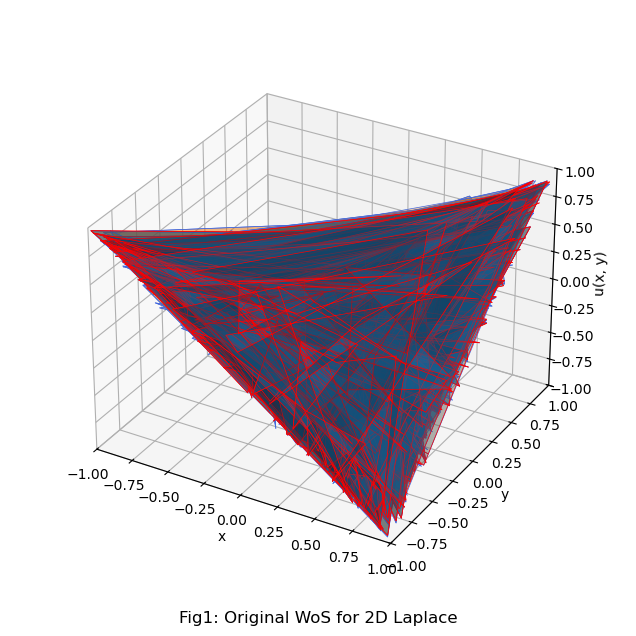

In [28]:
fig = plt.figure(figsize = (8, 8))
ax = fig.add_subplot(projection='3d')
X = target[:, 0].reshape(100, 100)
Y = target[:, 1].reshape(100, 100)
Z1 = X*Y

# Plot the 3D surface
#ax.plot_surface(X, Y, Z, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
#                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, result1.reshape(100, 100), edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='x', ylabel='y', zlabel = 'u(x, y)')
ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Fig1: Original WoS for 2D Laplace", y=-0.01)
#plt.show()
plt.savefig('WoSorgin2Dlaplace.png', bbox_inches='tight')

In [29]:
target = []
width = range(1, 100)
height = range(1, 100)
for i in width:
    for j in height:
        target.append(np.array([i/50 - 1, j/50 - 1]))
target1 = np.array(target).reshape(-1, 2).astype("float32")
X = target1[:, 0]
Y = target1[:, 1]
Z = []
for i in target1:
        Z.append(YNNmodel(np.array(i).reshape([1, 2]).astype("float32")))

X = np.array(X).reshape(99, 99)
Y = np.array(Y).reshape(99, 99)
Z = np.array(Z).reshape(99, 99)

(99, 99)


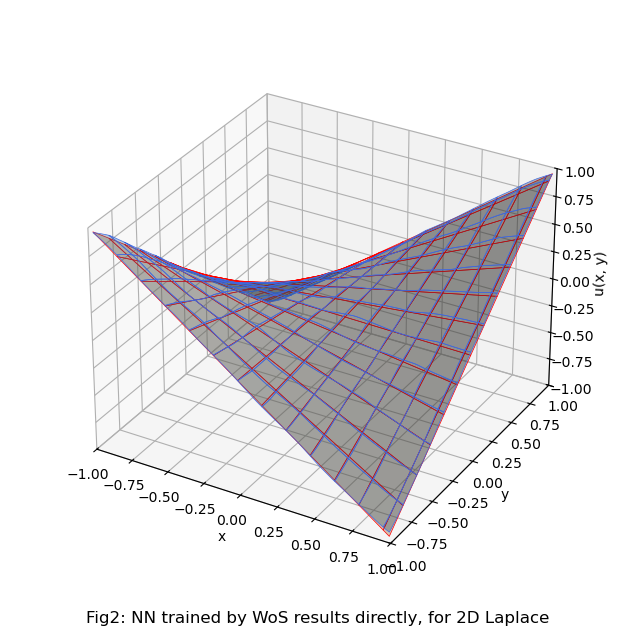

In [30]:
Z1 = X*Y
print(Z1.shape)

import matplotlib.pyplot as plt
fig = plt.figure(figsize = (8, 8))
ax = fig.add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
#ax.plot_surface(X, Y, Z2, edgecolor='green', lw=0.5, rstride=8, cstride=8,
#                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='x', ylabel='y', zlabel='u(x, y)')
ax.set_box_aspect(None, zoom=0.85)
ax.set_title("Fig2: NN trained by WoS results directly, for 2D Laplace", y=-0.01)
#plt.show()
plt.savefig('WoSsmoothed2Dlaplace.png', bbox_inches='tight')